<a href="https://colab.research.google.com/github/langfordzd/Synthetic_OPM_ML_Classification/blob/main/OPM_ML_TimeSeries_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Synthetic OPM ML Classification Pipeline

This notebook provides a **reusable ML analysis pipeline** for OPM-like biomedical time-series. It is inspired by real fetal OPM/MEG-style analysis problems, but it uses synthetic example data so that the workflow can be shared openly.

**What are OPMs?** Optically pumped magnetometers (OPMs) are highly sensitive magnetic-field sensors that can be used for MEG-style neurophysiology without cryogenic SQUID systems. In fetal OPM work, the practical ML problem is difficult: the useful signal can be weak, noisy, time-varying, and distributed across multiple sensors. This is exactly where an ML approach can be useful: rather than asking whether one sensor shows a clear effect, the classifier can learn whether a *pattern across sensors and time windows* carries condition-relevant information.

This notebook uses **synthetic data only**. It does not include real fetal recordings, participant data, hospital data, proprietary files, or project-specific parameters. The simulation is designed to resemble the *type* of low-SNR multichannel time-series problem encountered in OPM/MEG-style work, without reproducing any protected dataset.



## Why use ML here?

A traditional sensor-by-sensor analysis asks whether a single channel or a single time point shows a large enough difference between conditions. That can miss effects that are weak but distributed across several sensors. In this notebook, each trial is represented as a multichannel feature vector, so the model can combine small pieces of information from many OPM channels.

This is the main strength of the approach: it tests whether the *joint spatial pattern* across sensors is informative, even when no individual channel looks decisive on its own. The same logic is used in many industry ML settings: combine many noisy predictors into one validated classifier, then test whether performance generalizes to held-out data.

## What the notebook does

The notebook builds an end-to-end ML workflow for classifying weak condition-dependent structure in noisy biomedical time-series:

- simulate noisy multichannel OPM-like epochs
- add a small condition-dependent evoked response
- preprocess the signals with filtering and baseline correction
- extract response-window and sliding-window features
- train simple supervised classifiers using scikit-learn
- evaluate performance with group-aware cross-validation
- compare observed performance against a permutation-based null model
- run an effect-size / SNR sweep to verify that the pipeline behaves sensibly
- generate interpretable figures and result tables

The goal is to show how an ML pipeline can be used as a practical analysis tool for weak biomedical sensor signals, not to train a clinical fetal classifier.


## 1. Imports and configuration

This notebook runs directly in Google Colab and uses standard scientific Python / ML libraries: `numpy`, `scipy`, `scikit-learn`, `pandas`, and `matplotlib`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from scipy import signal

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)

## 2. Simulate synthetic OPM-like epochs

The simulation creates multichannel, time-locked epochs that resemble a difficult biomedical sensor-classification problem. Each epoch is a short time-series recorded from multiple synthetic OPM sensors.

The simulated data include common practical nuisances:

- correlated sensor noise
- low-frequency drift
- trial-level offsets
- subject/session variability
- latency jitter
- a weak condition-dependent evoked response

The binary labels are:

- `0`: baseline/control-like condition
- `1`: weak-response condition

This gives us a controlled example dataset for testing whether an ML pipeline can detect a weak signal without using any real fetal OPM recordings.

The condition effect is deliberately distributed across a subset of synthetic sensors. This is important: the classifier is not given one obvious “magic channel.” Instead, it has to use the pattern across multiple OPM channels, which is closer to the kind of low-SNR multichannel problem that motivated the ML analysis.


In [ ]:
@dataclass(frozen=True)
class SimulationConfig:
    n_subjects: int = 8
    trials_per_condition: int = 40
    n_channels: int = 12
    sfreq: float = 100.0
    tmin: float = -0.2
    tmax: float = 1.0
    condition_effect: float = 0.35
    random_state: int = 7

    @property
    def times(self):
        return np.arange(self.tmin, self.tmax, 1.0 / self.sfreq)


def gaussian_bump(times, center, width):
    return np.exp(-0.5 * ((times - center) / width) ** 2)


def make_sensor_covariance(n_channels, rng):
    idx = np.arange(n_channels)
    distance = np.abs(idx[:, None] - idx[None, :])
    cov = 0.55 ** distance
    jitter = rng.normal(scale=0.03, size=(n_channels, n_channels))
    cov += jitter @ jitter.T
    cov += np.eye(n_channels) * 0.1
    return cov


def pinkish_noise(shape, rng):
    """Low-frequency-heavy noise by filtering white noise.

    The noise level is intentionally high enough to keep the example realistic,
    but not so high that the injected multichannel condition effect disappears.
    """
    white = rng.normal(size=shape)
    b, a = signal.butter(2, 0.18, btype="low")
    low = signal.filtfilt(b, a, white, axis=-1)
    return 0.45 * white + 0.55 * low


def simulate_epochs(config):
    rng = np.random.default_rng(config.random_state)
    times = config.times
    n_times = times.size
    n_epochs = config.n_subjects * config.trials_per_condition * 2

    X = np.zeros((n_epochs, config.n_channels, n_times), dtype=float)
    y = np.zeros(n_epochs, dtype=int)
    groups = np.zeros(n_epochs, dtype=int)

    sensor_cov = make_sensor_covariance(config.n_channels, rng)
    mixing = np.linalg.cholesky(sensor_cov)

    # A broad, low-SNR evoked pattern.
    # The effect is not a single-channel spike; it is distributed over sensors.
    base_evoked = (
        1.20 * gaussian_bump(times, center=0.30, width=0.09)
        - 0.70 * gaussian_bump(times, center=0.52, width=0.11)
    )
    base_evoked[times < 0] = 0.0

    # Spatial weights: only some channels carry reliable signal.
    # This is the key multichannel ML point: the class information is distributed
    # across sensors rather than isolated to one large univariate effect.
    channel_weights = rng.normal(loc=0.0, scale=0.10, size=config.n_channels)
    informative = np.array([1, 3, 5, 8, 10, 11])
    informative = informative[informative < config.n_channels]
    signs = np.array([1.0, -1.0, 1.0, -1.0, 1.0, -1.0])[: informative.size]
    channel_weights[informative] += signs
    channel_weights /= np.linalg.norm(channel_weights)

    row = 0
    for subject in range(config.n_subjects):
        subject_gain = rng.lognormal(mean=0.0, sigma=0.15)
        latency_shift = rng.normal(loc=0.0, scale=0.015)
        shifted_evoked = (
            1.00 * gaussian_bump(times, center=0.28 + latency_shift, width=0.08)
            - 0.55 * gaussian_bump(times, center=0.48 + latency_shift, width=0.10)
        )
        shifted_evoked[times < 0] = 0.0

        for label in (0, 1):
            noise = pinkish_noise((config.trials_per_condition, config.n_channels, n_times), rng)
            noise = np.einsum("ij,tjn->tin", mixing, noise)  # cross-channel covariance

            drift_coef = rng.normal(scale=0.20, size=(config.trials_per_condition, config.n_channels, 1))
            drift = drift_coef * np.linspace(-0.5, 0.5, n_times)[None, None, :]
            offsets = rng.normal(scale=0.15, size=(config.trials_per_condition, config.n_channels, 1))

            epochs = noise + drift + offsets
            if label == 1:
                amplitude = config.condition_effect * subject_gain
                trial_jitter = rng.normal(loc=1.0, scale=0.08, size=(config.trials_per_condition, 1, 1))
                response = amplitude * trial_jitter * channel_weights[None, :, None] * shifted_evoked[None, None, :]
                epochs = epochs + response

            rows = slice(row, row + config.trials_per_condition)
            X[rows] = epochs
            y[rows] = label
            groups[rows] = subject
            row += config.trials_per_condition

    order = rng.permutation(n_epochs)
    return X[order], y[order], groups[order], times

## 3. Preprocessing and feature extraction

The preprocessing is intentionally simple and transparent:

1. band-pass filter the synthetic epochs
2. subtract the pre-stimulus baseline
3. average each channel within a response window for classification

The important ML detail is that feature scaling happens **inside the cross-validation pipeline**, so information from the test folds does not leak into the training folds.

After response-window averaging, each trial is represented by one value per channel. For example, with 12 sensors, one trial becomes a 12-feature vector. The model is therefore learning from the multichannel sensor pattern, not from a single averaged waveform.


In [ ]:
def bandpass_epochs(X, sfreq, low=0.5, high=30.0):
    nyq = sfreq / 2.0
    b, a = signal.butter(3, [low / nyq, high / nyq], btype="band")
    return signal.filtfilt(b, a, X, axis=-1)


def baseline_correct(X, times, baseline=(-0.2, 0.0)):
    mask = (times >= baseline[0]) & (times <= baseline[1])
    return X - X[..., mask].mean(axis=-1, keepdims=True)


def window_features(X, times, window=(0.20, 0.55)):
    mask = (times >= window[0]) & (times <= window[1])
    return X[..., mask].mean(axis=-1)


def sliding_window_features(X, times, window_size=0.08, step=0.02):
    starts = np.arange(times.min(), times.max() - window_size + step / 2, step)
    features = []
    centers = []
    for s in starts:
        e = s + window_size
        mask = (times >= s) & (times < e)
        if mask.sum() >= 2:
            features.append(X[..., mask].mean(axis=-1))
            centers.append((s + e) / 2)
    return features, np.asarray(centers)

## 4. ML model and cross-validation helpers

The default model is regularized logistic regression, a strong baseline for many tabular/time-window classification tasks. LDA is included as a second simple linear classifier because it is common in neurophysiology signal-classification workflows.

Synthetic trials are grouped by synthetic subject, so the notebook uses `StratifiedGroupKFold`: the same subject cannot appear in both train and test folds. This is a stricter and more more realistic validation setup than randomly mixing all trials, because it tests whether the learned pattern generalizes to held-out subjects.

In [ ]:
def make_classifier(kind="logistic"):
    if kind == "logistic":
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear"),
        )
    if kind == "lda":
        return make_pipeline(
            StandardScaler(),
            LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
        )
    raise ValueError(f"Unknown classifier kind: {kind}")


def cross_validated_predictions(X_features, y, groups=None, classifier="logistic", n_splits=3, random_state=7):
    if groups is not None:
        cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        splits = cv.split(X_features, y, groups)
    else:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        splits = cv.split(X_features, y)

    y_true_all, y_pred_all, y_score_all = [], [], []
    for train_idx, test_idx in splits:
        model = make_classifier(classifier)
        model.fit(X_features[train_idx], y[train_idx])
        y_pred = model.predict(X_features[test_idx])
        y_score = model.predict_proba(X_features[test_idx])[:, 1]
        y_true_all.append(y[test_idx])
        y_pred_all.append(y_pred)
        y_score_all.append(y_score)

    return np.concatenate(y_true_all), np.concatenate(y_pred_all), np.concatenate(y_score_all)


def cross_validated_scores(X_features, y, groups=None, classifier="logistic", n_splits=3, random_state=7):
    y_true, y_pred, y_score = cross_validated_predictions(
        X_features, y, groups=groups, classifier=classifier, n_splits=n_splits, random_state=random_state
    )
    return {
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }


def time_resolved_decoding(feature_matrices, y, groups=None, classifier="logistic", n_splits=3, random_state=7):
    scores = []
    for X_features in feature_matrices:
        score = cross_validated_scores(
            X_features, y, groups=groups, classifier=classifier, n_splits=n_splits, random_state=random_state
        )["balanced_accuracy"]
        scores.append(score)
    return np.asarray(scores)

## 5. Plotting helpers

In [ ]:
def plot_evoked_difference(X, y, times):
    gfp = X.mean(axis=1)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for label in sorted(np.unique(y)):
        mean = gfp[y == label].mean(axis=0)
        se = gfp[y == label].std(axis=0) / np.sqrt((y == label).sum())
        ax.plot(times, mean, label=f"condition {label}")
        ax.fill_between(times, mean - se, mean + se, alpha=0.2)
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_xlabel("Time from stimulus onset (s)")
    ax.set_ylabel("Mean signal across sensors (a.u.)")
    ax.set_title("Synthetic OPM-like evoked responses")
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig, ax


def plot_time_resolved_decoding(centers, scores, p_values=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(centers, scores, label="balanced accuracy")
    ax.axhline(0.5, linestyle="--", linewidth=1, label="chance")
    ax.axvline(0, linestyle="--", linewidth=1)
    if p_values is not None:
        sig = p_values < 0.05
        if np.any(sig):
            ax.scatter(centers[sig], scores[sig], s=18, label="p < .05, pointwise")
    ax.set_xlabel("Window center (s)")
    ax.set_ylabel("Balanced accuracy")
    ax.set_ylim(0.35, 0.80)
    ax.set_title("Time-resolved ML classification of synthetic condition differences")
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig, ax


def plot_snr_sweep(effects, scores, errors=None):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    if errors is None:
        ax.plot(effects, scores, marker="o")
    else:
        ax.errorbar(effects, scores, yerr=errors, marker="o", capsize=4)
    ax.axhline(0.5, linestyle="--", linewidth=1, label="chance")
    ax.set_xlabel("Simulated condition-effect amplitude")
    ax.set_ylabel("Balanced accuracy")
    ax.set_ylim(0.45, 1.02)
    ax.set_title("Classification improves as the synthetic multichannel signal gets stronger")
    ax.legend(frameon=False)
    fig.tight_layout()
    return fig, ax

## 6. Generate and inspect the synthetic dataset

This section creates the synthetic OPM-like dataset and visualizes the average evoked response. The plot is not expected to look perfectly clean; the point is to mimic a low-SNR setting where classification may reveal structure that is hard to see by eye.

In [ ]:
config = SimulationConfig(condition_effect=0.60, random_state=RANDOM_STATE)
X_raw, y, groups, times = simulate_epochs(config)

X = bandpass_epochs(X_raw, sfreq=config.sfreq, low=0.5, high=30.0)
X = baseline_correct(X, times, baseline=(-0.2, 0.0))

print("Epoch array shape:", X.shape)  # epochs x channels x time
print("Labels:", dict(zip(*np.unique(y, return_counts=True))))
print("Synthetic subjects:", np.unique(groups))
print("Time range:", (times.min(), times.max()))

Epoch array shape: (640, 12, 120)
Labels: {np.int64(0): np.int64(320), np.int64(1): np.int64(320)}
Synthetic subjects: [0 1 2 3 4 5 6 7]
Time range: (np.float64(-0.2), np.float64(0.9900000000000011))


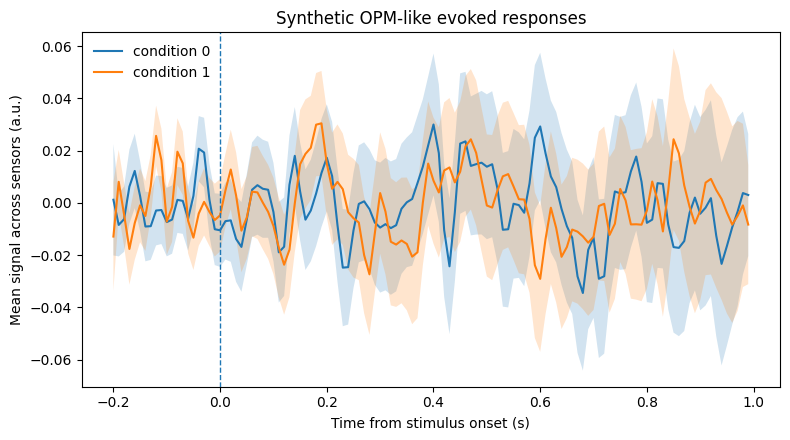

In [ ]:
fig, ax = plot_evoked_difference(X, y, times)
plt.show()

## 7. Response-window ML classification

Here each trial is converted into a multichannel feature vector.

The synthetic evoked response is biphasic, so the feature window is chosen to capture the main informative deflection rather than averaging across the later opposite-polarity component. Averaging too broadly can cancel the signal and make the classifier look artificially weak.

Conceptually:

```text
trial 1 → [sensor_1, sensor_2, ..., sensor_12] → condition label
```

This is the core strength of the ML approach: it can combine weak distributed information across sensors rather than relying on one large single-channel effect.

In [ ]:
X_features = window_features(X, times, window=(0.20, 0.35))

summary_rows = []
for clf in ["logistic", "lda"]:
    scores = cross_validated_scores(
        X_features,
        y,
        groups=groups,
        classifier=clf,
        n_splits=4,
        random_state=RANDOM_STATE,
    )
    summary_rows.append({
        "classifier": clf,
        "balanced_accuracy": scores["balanced_accuracy"],
        "roc_auc": scores["roc_auc"],
    })

summary = pd.DataFrame(summary_rows)
summary

,classifier,balanced_accuracy,roc_auc
0,logistic,0.665625,0.737275
1,lda,0.656250,0.734863


In [ ]:
y_true, y_pred, y_score = cross_validated_predictions(
    X_features,
    y,
    groups=groups,
    classifier="lda",
    n_splits=4,
    random_state=RANDOM_STATE,
)

cm = confusion_matrix(y_true, y_pred)
print("LDA confusion matrix")
print(cm)

LDA confusion matrix
[[210 110]
 [110 210]]


## 8. Permutation test

The permutation test asks whether the observed ML classification score is larger than expected if the labels were unrelated to the signals.

For speed in Colab, this uses 100 permutations. For a more serious analysis, increase this to 500 or 1000.

In [ ]:
def permutation_test_score(
    X_features,
    y,
    groups=None,
    classifier="lda",
    n_permutations=50,
    random_state=7,
):
    rng = np.random.default_rng(random_state)
    observed = cross_validated_scores(
        X_features,
        y,
        groups=groups,
        classifier=classifier,
        n_splits=4,
        random_state=random_state,
    )["balanced_accuracy"]

    null = np.empty(n_permutations)
    for i in range(n_permutations):
        y_perm = rng.permutation(y)
        null[i] = cross_validated_scores(
            X_features,
            y_perm,
            groups=groups,
            classifier=classifier,
            n_splits=4,
            random_state=random_state + i + 1,
        )["balanced_accuracy"]

    p_value = (1.0 + np.sum(null >= observed)) / (n_permutations + 1.0)
    return observed, null, p_value

observed, null, p_value = permutation_test_score(
    X_features,
    y,
    groups=groups,
    classifier="lda",
    n_permutations=50,
    random_state=RANDOM_STATE,
)
print(f"Observed balanced accuracy: {observed:.3f}")
print(f"Permutation p-value: {p_value:.4f}")

Observed balanced accuracy: 0.656
Permutation p-value: 0.0196


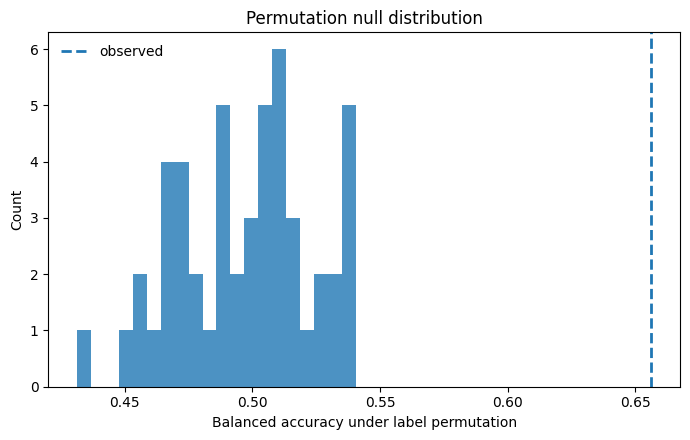

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(null, bins=20, alpha=0.8)
ax.axvline(observed, linestyle="--", linewidth=2, label="observed")
ax.set_xlabel("Balanced accuracy under label permutation")
ax.set_ylabel("Count")
ax.set_title("Permutation null distribution")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 9. Time-resolved ML classification

Instead of using one fixed response window, this section trains and evaluates the classifier in short sliding time windows.

This answers a practical question: **when** does the signal contain condition-relevant information? In neuroscience this is often called time-resolved decoding; in general ML language, it is sliding-window classification for multichannel time-series.

The p-values below are pointwise and uncorrected. For production or publication-level analysis, temporal autocorrelation and multiple comparisons should be handled more carefully.

At each window, the classifier again uses all channels as features. The output is therefore not just “which time point is large?” but “when does the multichannel sensor pattern become predictive of the condition?”


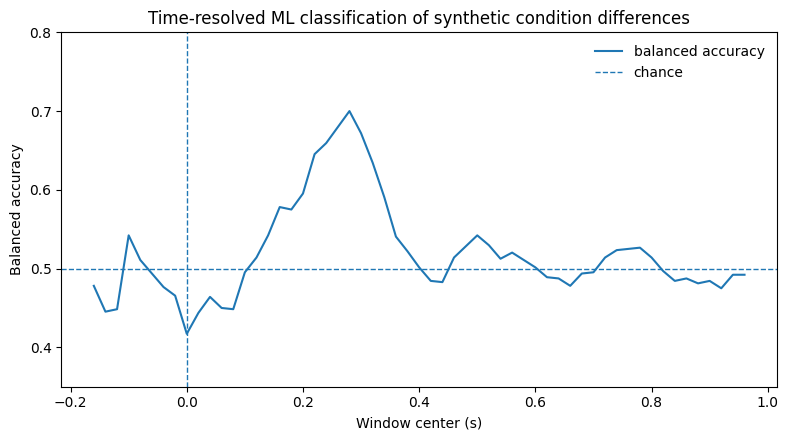

In [ ]:
feature_matrices, centers = sliding_window_features(X, times, window_size=0.08, step=0.02)
time_scores = time_resolved_decoding(feature_matrices, y, groups=groups, classifier="logistic", n_splits=3)

# Fast pointwise permutation test for time-resolved decoding.
rng = np.random.default_rng(RANDOM_STATE)
n_perm_time = 15
null_time = np.empty((n_perm_time, len(feature_matrices)))
for i in range(n_perm_time):
    y_perm = rng.permutation(y)
    null_time[i] = time_resolved_decoding(
        feature_matrices, y_perm, groups=groups, classifier="logistic", n_splits=3, random_state=RANDOM_STATE + i + 1
    )

p_values = (1.0 + np.sum(null_time >= time_scores[None, :], axis=0)) / (n_perm_time + 1.0)

fig, ax = plot_time_resolved_decoding(centers, time_scores, p_values=p_values)
plt.show()

## 10. Effect-size / SNR sweep

A useful sanity check is to repeat the full simulation while changing the size of the synthetic condition effect.

If the pipeline is working, accuracy should be close to chance when the effect is zero and should increase as the injected multichannel signal becomes stronger.

To make the trend stable, this cell averages each effect size over several random seeds. This avoids overinterpreting one lucky or unlucky simulation run.

In [ ]:
effects = np.array([0.00, 0.20, 0.40, 0.60, 0.80, 1.00])
seeds = np.arange(10, 20)  # repeated simulations for a more stable trend
sweep_rows = []

for effect in effects:
    seed_scores = []
    seed_aucs = []

    for seed in seeds:
        cfg = SimulationConfig(condition_effect=float(effect), random_state=int(seed))
        X_raw_i, y_i, groups_i, times_i = simulate_epochs(cfg)
        X_i = bandpass_epochs(X_raw_i, sfreq=cfg.sfreq, low=0.5, high=30.0)
        X_i = baseline_correct(X_i, times_i, baseline=(-0.2, 0.0))

        # Use the same response window as the main classifier.
        # This targets the informative part of the synthetic evoked response.
        X_feat_i = window_features(X_i, times_i, window=(0.20, 0.35))

        scores_i = cross_validated_scores(
            X_feat_i,
            y_i,
            groups=groups_i,
            classifier="lda",
            n_splits=4,
            random_state=int(seed),
        )
        seed_scores.append(scores_i["balanced_accuracy"])
        seed_aucs.append(scores_i["roc_auc"])

    sweep_rows.append({
        "condition_effect": effect,
        "mean_balanced_accuracy": np.mean(seed_scores),
        "se_balanced_accuracy": np.std(seed_scores, ddof=1) / np.sqrt(len(seed_scores)),
        "mean_roc_auc": np.mean(seed_aucs),
        "se_roc_auc": np.std(seed_aucs, ddof=1) / np.sqrt(len(seed_aucs)),
    })

sweep = pd.DataFrame(sweep_rows)
sweep

,condition_effect,mean_balanced_accuracy,se_balanced_accuracy,mean_roc_auc,se_roc_auc
0,0.0,0.502656,0.006898,0.500265,0.009288
1,0.2,0.537500,0.010579,0.552771,0.011973
2,0.4,0.606250,0.007168,0.642250,0.009157
3,0.6,0.663438,0.007673,0.721462,0.007926
4,0.8,0.715937,0.008055,0.788090,0.007262
5,1.0,0.763437,0.007112,0.843006,0.006543


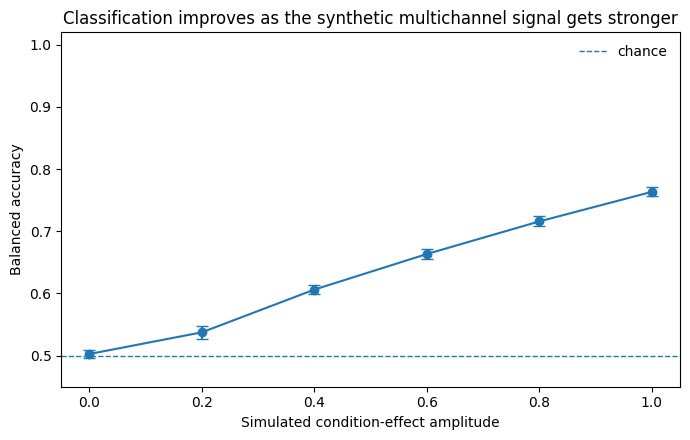

In [ ]:
fig, ax = plot_snr_sweep(
    sweep["condition_effect"].to_numpy(),
    sweep["mean_balanced_accuracy"].to_numpy(),
    errors=sweep["se_balanced_accuracy"].to_numpy(),
)
plt.show()

## 11. Interpretation

This notebook shows a practical ML workflow for synthetic OPM-like biomedical time-series.

The main methodological point is multichannel classification. Each trial is represented by a vector of responses across OPM sensors. The classifier can therefore test whether the joint spatial pattern across sensors is informative, even when no single channel would be convincing by itself.

The effect-size sweep is a sanity check. When no condition effect is injected, performance should be close to chance. As the simulated condition difference becomes stronger, balanced accuracy should increase. That pattern shows that the pipeline is responding to the intended multichannel signal rather than producing arbitrary above-chance results.

One practical lesson is that feature definition matters. The simulated response is biphasic, so a very broad averaging window can cancel positive and negative parts of the response. The response-window classifier therefore uses the earlier informative deflection, while the time-resolved analysis shows when information is available without requiring one fixed window.

The data here are synthetic. This is not a clinical fetal classifier and it does not use private recordings. It is a shareable analysis workflow for weak-signal classification problems similar to those encountered in OPM/MEG-style data.